In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(69)


## Loading Dataset

In [2]:
#Google
from torch.utils.data import DataLoader
# 1. Define transformations
# Converts images to PyTorch tensors and scales pixel values to [0, 1]
transform = transforms.ToTensor()

# 2. Load the training dataset
train_data = torchvision.datasets.FashionMNIST(
    root='data',          # Root directory where the dataset is stored
    train=True,           # Specify training data
    download=True,        # Download the dataset if not already present
    transform=transform   # Apply the defined transformation
)

# 3. Load the test dataset
test_data = torchvision.datasets.FashionMNIST(
    root='data',
    train=False,          # Specify test data
    download=True,
    transform=transform
)

# 4. Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

len(train_loader), len(test_loader)

(938, 157)

# Part 1: Tensors, Autograd & The "Forward Pass"

In [3]:
#Tensor creation & flattening

x = torch.randn(32,1,28,28)
x_flat = torch.flatten(x)

x.shape, x_flat.shape

(torch.Size([32, 1, 28, 28]), torch.Size([25088]))

In [4]:
#Manual Linear Forward Pass
X = torch.randn(5,10)
W = torch.randn(3,10)
B = torch.randn(3)

Y = X @ W.t() + B
Y

tensor([[ 0.2174, -0.3750, -4.7971],
        [ 2.8862,  2.5441, -4.4447],
        [ 0.6459,  3.7314, -0.5315],
        [ 1.1367,  0.9484, -2.9892],
        [ 0.6721,  2.3745, -1.0638]])

In [5]:
#Autograd

X = torch.randn(5,10)
W = torch.randn(3,10, requires_grad=True)

Y = X @ W.t()
loss = Y.sum()

loss.backward()
W.grad[:2]

tensor([[-4.9200,  0.6244,  0.8428, -1.1427, -3.9183, -3.3109,  0.5202, -0.1276,
          2.9831,  0.7463],
        [-4.9200,  0.6244,  0.8428, -1.1427, -3.9183, -3.3109,  0.5202, -0.1276,
          2.9831,  0.7463]])

# Part 2: FFNN, Loss & Gradient Descent (The Training Loop)

In [6]:
class SimpleANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,10)

    def forward(self,x):
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [7]:
lossfn = nn.CrossEntropyLoss()


In [8]:
model = SimpleANN()
lr = 0.01
loss_history = []

for epoch in range(5):
    total_loss = 0
    for imgs, labels in train_loader:
        outputs = model(imgs)
        loss = lossfn(outputs, labels)
        loss.backward()
        with torch.no_grad():
            for p in model.parameters():
                p -= lr * p.grad
        model.zero_grad()
        total_loss += loss.item()
    loss_history.append(total_loss)
    print("Epoch", epoch, "\t | Loss:", total_loss)


Epoch 0 	 | Loss: 1294.9130222797394
Epoch 1 	 | Loss: 671.4683749973774
Epoch 2 	 | Loss: 560.474061280489
Epoch 3 	 | Loss: 503.5555284321308
Epoch 4 	 | Loss: 472.4425226300955


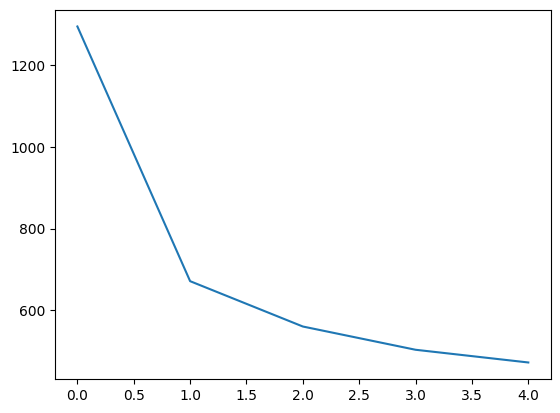

In [9]:
plt.plot(loss_history)
plt.show()

# PART 3 — Regularization & Dropout

In [10]:
small_subset = torch.utils.data.Subset(train_data, range(100))
small_loader = torch.utils.data.DataLoader(small_subset, batch_size=32, shuffle=True)


In [11]:
#GPT

class DropoutANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.drop1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256,128)
        self.drop2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128,10)

    def forward(self,x):
        x = x.view(x.size(0),-1)
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        return self.fc3(x)


In [12]:
drop_model = DropoutANN()
optimizer = torch.optim.Adam(drop_model.parameters(), lr=0.001)

train_loss = []
val_loss = []

for epoch in range(30):
    drop_model.train()
    for imgs, labels in small_loader:
        outputs = drop_model(imgs)
        loss = lossfn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(loss.item())

    drop_model.eval()
    with torch.no_grad():
        imgs, labels = next(iter(test_loader))
        outputs = drop_model(imgs)
        v_loss = lossfn(outputs, labels)
        val_loss.append(v_loss.item())
    print(f"Epoch {epoch} \t| Train Loss: {train_loss[-1]:.2f} | Val Loss: {val_loss[-1]:.2f}")

print("Training complete")


Epoch 0 	| Train Loss: 2.34 | Val Loss: 2.24
Epoch 1 	| Train Loss: 2.32 | Val Loss: 2.19
Epoch 2 	| Train Loss: 2.09 | Val Loss: 2.15
Epoch 3 	| Train Loss: 2.48 | Val Loss: 2.09
Epoch 4 	| Train Loss: 2.01 | Val Loss: 2.00
Epoch 5 	| Train Loss: 1.80 | Val Loss: 1.90
Epoch 6 	| Train Loss: 1.58 | Val Loss: 1.80
Epoch 7 	| Train Loss: 1.53 | Val Loss: 1.72
Epoch 8 	| Train Loss: 0.70 | Val Loss: 1.63
Epoch 9 	| Train Loss: 0.74 | Val Loss: 1.57
Epoch 10 	| Train Loss: 1.26 | Val Loss: 1.51
Epoch 11 	| Train Loss: 1.45 | Val Loss: 1.42
Epoch 12 	| Train Loss: 1.48 | Val Loss: 1.36
Epoch 13 	| Train Loss: 0.55 | Val Loss: 1.30
Epoch 14 	| Train Loss: 1.05 | Val Loss: 1.25
Epoch 15 	| Train Loss: 0.99 | Val Loss: 1.22
Epoch 16 	| Train Loss: 0.96 | Val Loss: 1.20
Epoch 17 	| Train Loss: 0.66 | Val Loss: 1.15
Epoch 18 	| Train Loss: 0.40 | Val Loss: 1.11
Epoch 19 	| Train Loss: 0.24 | Val Loss: 1.11
Epoch 20 	| Train Loss: 0.73 | Val Loss: 1.11
Epoch 21 	| Train Loss: 0.39 | Val Loss: 1.0

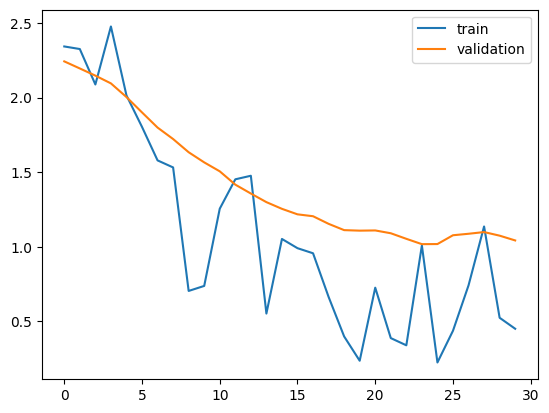

In [13]:
plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.legend()
plt.show()


# Part 4: Fundamentals of CNN (Convolutional Neural Networks)

In [14]:
#Google

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,32,3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32,64,3)
        self.fc1 = nn.Linear(64*5*5,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [15]:
cnn = SimpleCNN()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

for epoch in range(5):
    for imgs, labels in train_loader:

        outputs = cnn(imgs)
        loss = lossfn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch", epoch, "Loss:", loss.item())


Epoch 0 Loss: 0.33028164505958557
Epoch 1 Loss: 0.18356192111968994
Epoch 2 Loss: 0.3197411596775055
Epoch 3 Loss: 0.19913877546787262
Epoch 4 Loss: 0.2818116843700409


In [16]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

ann_acc = accuracy(model, test_loader)
dann_acc = accuracy(drop_model,test_loader)
cnn_acc = accuracy(cnn, test_loader)

print("ANN Accuracy:", ann_acc)
print("Dropout ANN Accuracy:", dann_acc)
print("CNN Accuracy:", cnn_acc)


ANN Accuracy: 0.8118
Dropout ANN Accuracy: 0.6316
CNN Accuracy: 0.901
